# 02 — Entrenamiento y evaluación de modelos — EnergiAI (Bloque C)

Entrena, compara y serializa el modelo que clasifica un consumo como *Eficiente*,
*Moderado* o *Ineficiente*, a partir del dataset del Bloque A y los criterios del Bloque B.

**Métrica principal: F1 macro** — pondera las tres clases por igual, protegiendo a las
minoritarias (a diferencia del accuracy, que un modelo trivial podría inflar).

**Estructura:** 1) Carga y split · 2) Baseline (Regresión Logística) · 3) Candidatos
(Árbol y Random Forest + GridSearch) · 4) Comparación y elección · 5) Feature importance ·
6) Serialización · 7) Prueba del ejemplo del brief.

Contrato del modelo: se serializa el **pipeline completo** (preprocesamiento + modelo),
para que el Servicio ML (Bloque D) le pase datos crudos con los mismos nombres de columna.

## 1. Carga y split estratificado

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42

# Columnas segun el Contrato 3 (los nombres son parte del contrato con el Bloque D)
FEATURES_CAT = ["tipo_inmueble"]
FEATURES_NUM = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo"]
FEATURES_BOOL = ["uso_horario_pico"]
FEATURES = FEATURES_CAT + FEATURES_NUM + FEATURES_BOOL
TARGET = "categoria"

CANDIDATOS = [Path("../data/dataset_energia.csv"), Path("data-science/data/dataset_energia.csv")]
RUTA_CSV = next(p for p in CANDIDATOS if p.exists())
df = pd.read_csv(RUTA_CSV)
X = df[FEATURES]
y = df[TARGET]
print(f"Dataset: {len(df)} filas | features: {FEATURES} | target: {TARGET}")
df.head()

Dataset: 4000 filas | features: ['tipo_inmueble', 'consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'uso_horario_pico'] | target: categoria


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,202.54,False,2,Departamento,12,Ineficiente
1,225.13,True,6,Casa,7,Eficiente
2,920.43,True,13,Local,10,Ineficiente
3,218.95,False,5,Departamento,7,Moderado
4,170.40,False,8,Casa,6,Eficiente


In [2]:
# Split estratificado: conserva la proporcion de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train: {len(X_train)}  |  test: {len(X_test)}")
print("\nProporcion de clases (train):")
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print("\nProporcion de clases (test):")
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

train: 3200  |  test: 800

Proporcion de clases (train):
categoria
Ineficiente    35.0
Eficiente      32.8
Moderado       32.2

Proporcion de clases (test):
categoria
Ineficiente    35.0
Eficiente      32.9
Moderado       32.1


In [3]:
# Preprocesamiento compartido por todos los modelos: OneHot al tipo, escalado a las numericas.
# uso_horario_pico pasa tal cual (0/1) por remainder='passthrough'.
def build_preproc():
    return ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
            ("num", StandardScaler(), FEATURES_NUM),
        ],
        remainder="passthrough",
    )


# Guardaremos aqui las metricas de cada modelo para la tabla comparativa final (seccion 4).
resultados = {}


def evaluar(nombre, pipe):
    """Entrena, evalua en test y con CV 5-fold, y registra las metricas."""
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    cv = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
    resultados[nombre] = {"accuracy": acc, "f1_macro": f1,
                          "cv_f1_mean": cv.mean(), "cv_f1_std": cv.std()}
    print(f"{nombre}\n  accuracy = {acc:.3f}\n  f1_macro = {f1:.3f}"
          f"\n  cv f1_macro = {cv.mean():.3f} +/- {cv.std():.3f}\n")
    print(classification_report(y_test, pred))
    return pipe, pred

## 2. Baseline — Regresión Logística

Siempre se empieza por un modelo simple e interpretable: da un piso de referencia contra
el cual justificar (o no) modelos más complejos.

In [4]:
pipe_logreg = Pipeline([
    ("preproc", build_preproc()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_logreg, pred_logreg = evaluar("LogisticRegression", pipe_logreg)

LogisticRegression
  accuracy = 0.932
  f1_macro = 0.932
  cv f1_macro = 0.938 +/- 0.006

              precision    recall  f1-score   support

   Eficiente       0.95      0.97      0.96       263
 Ineficiente       0.94      0.95      0.94       280
    Moderado       0.90      0.88      0.89       257

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



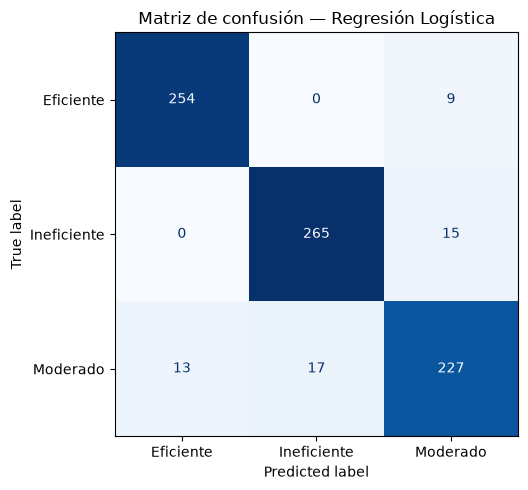

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False,
                                        cmap="Blues")
ax.set_title("Matriz de confusión — Regresión Logística")
plt.tight_layout()
plt.show()

El baseline ya alcanza un **F1 macro ~0.93**: el problema es bastante separable (esperable,
porque las etiquetas vienen de una fórmula por reglas del Bloque B). La confusión que queda
se concentra en la frontera *Moderado* ↔ vecinas, justo donde el índice está cerca de un umbral.
En las siguientes secciones vemos si un modelo no lineal mejora esto lo suficiente como para
justificar perder interpretabilidad.